In [ ]:

# Installing required library
! pip install sentence-transformers matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\kunal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to dismiss the player",
    "The team won the match by chasing a high target",
    "The captain set an aggressive field placement",
    
    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "The recipe includes spices and herbs for better flavor",
    
    # Cybersecurity (3)
    "Strong passwords help protect user accounts from hacking",
    "Encryption ensures that sensitive data remains secure",
    "Firewalls prevent unauthorized access to networks"
]

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

c:\Users\kunal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kunal\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7173.44it/s]
BertMo

Embedding shape: (10, 384)


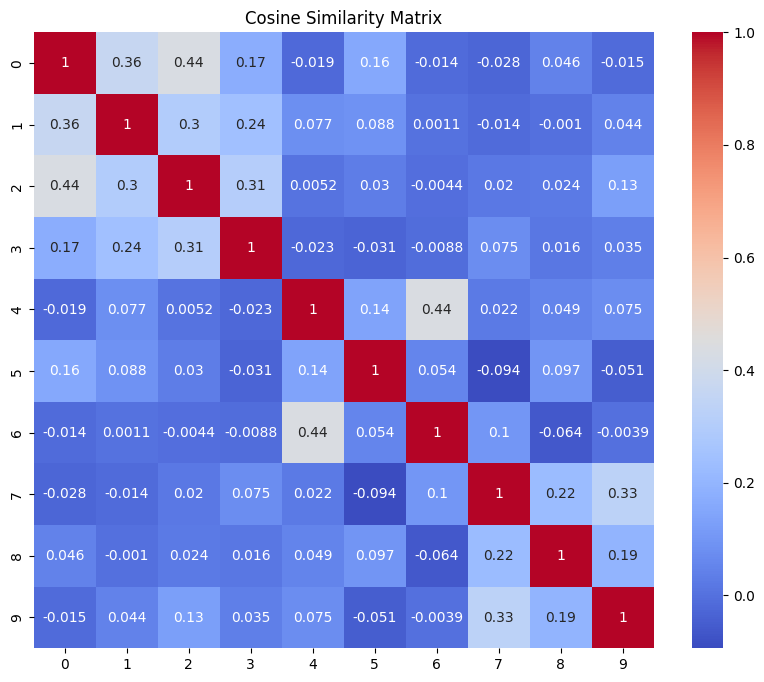

In [6]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(sentences[idx])
    print(similarities[idx])

The batsman scored a century in the final match
0.5706848
The bowler delivered a fast yorker to dismiss the player
0.5077524
